# Importing the Dependencies

In [523]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn import metrics
from sklearn.model_selection import KFold, cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Data Collection and Merging

In [524]:
# loading the data from csv file to a Pandas DataFrame
calories = pd.read_csv('calories.csv')

In [525]:
calories.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [526]:
exercise_data=pd.read_csv('exercise.csv')

In [527]:
exercise_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [528]:
df = pd.concat([exercise_data, calories['Calories']], axis=1)

In [529]:
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


# Data Cleaning and Processing

In [530]:
# Checking the number of rows and columns
df.shape

(15000, 9)

In [531]:
# Getting some information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [532]:
# Checking the missing value
df.isnull().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [533]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [534]:
df.duplicated().sum()

np.int64(0)

In [535]:
#check number of unique values in each feature
df.nunique()

User_ID       15000
Gender            2
Age              60
Height           90
Weight           91
Duration         30
Heart_Rate       59
Body_Temp        45
Calories        277
dtype: int64

# EDA

## Univariate Analysis Of Numerical Feature

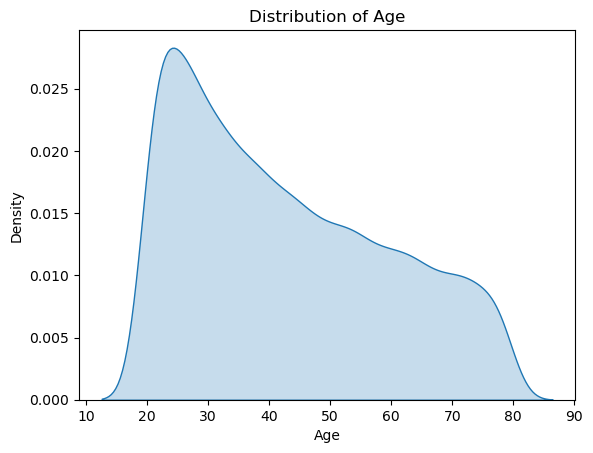

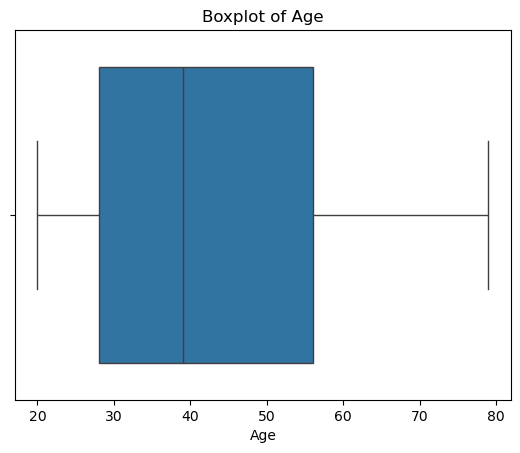

In [536]:
#Kde Plot
sns.kdeplot(data=df,x='Age',fill=True)
plt.title('Distribution of Age')
plt.show()

#BoxPlot
sns.boxplot(x=df['Age'])
plt.title('Boxplot of Age')
plt.show()

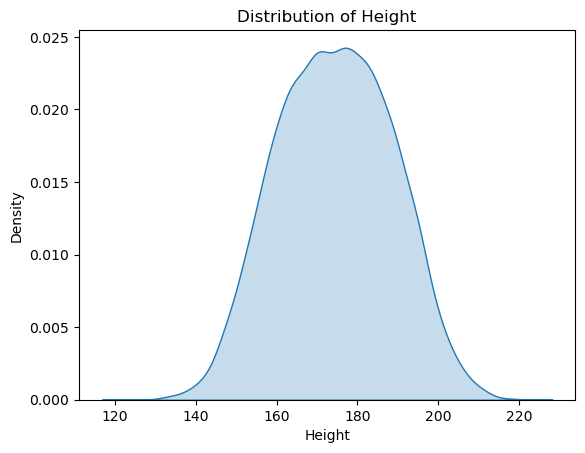

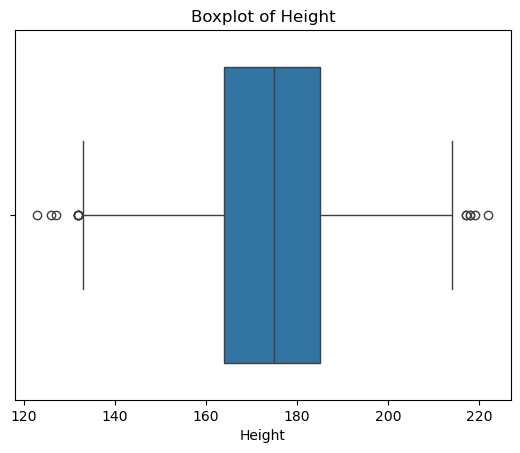

In [537]:
#Kde Plot
sns.kdeplot(data=df,x='Height',fill=True)
plt.title('Distribution of Height')
plt.show()

#BoxPlot
sns.boxplot(x=df['Height'])
plt.title('Boxplot of Height')
plt.show()

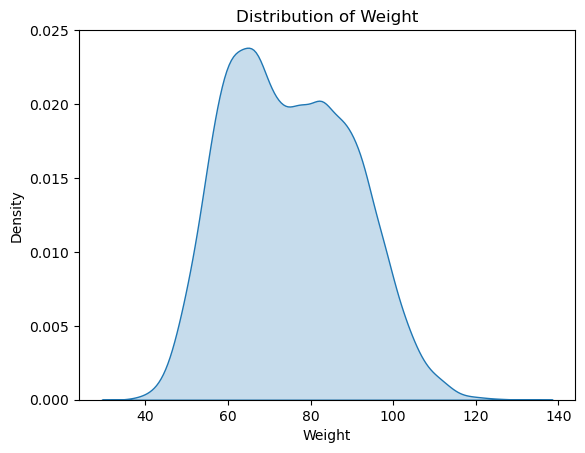

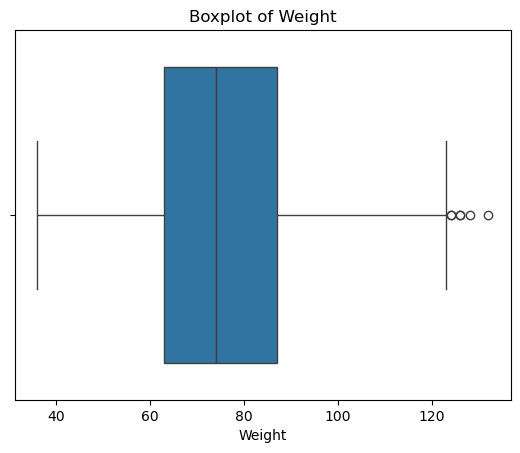

In [538]:
#Kde Plot
sns.kdeplot(data=df,x='Weight',fill=True)
plt.title('Distribution of Weight')
plt.show()

#BoxPlot
sns.boxplot(x=df['Weight'])
plt.title('Boxplot of Weight')
plt.show()

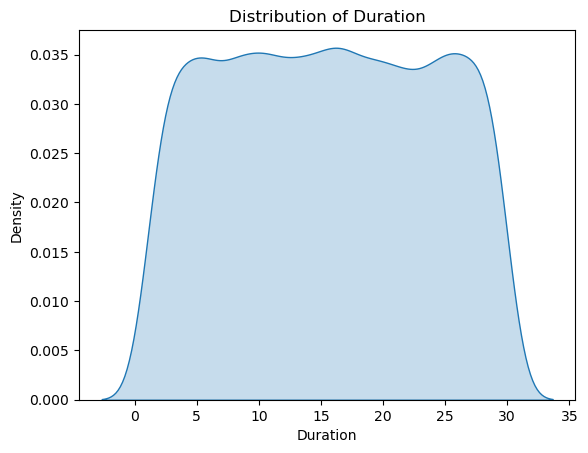

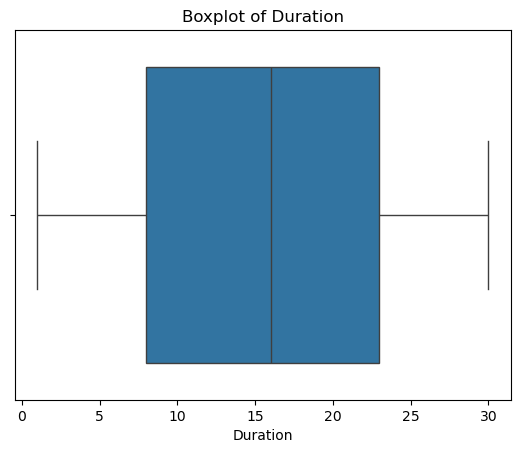

In [539]:
#Kde Plot
sns.kdeplot(data=df,x='Duration',fill=True)
plt.title('Distribution of Duration')
plt.show()

#BoxPlot
sns.boxplot(x=df['Duration'])
plt.title('Boxplot of Duration')
plt.show()

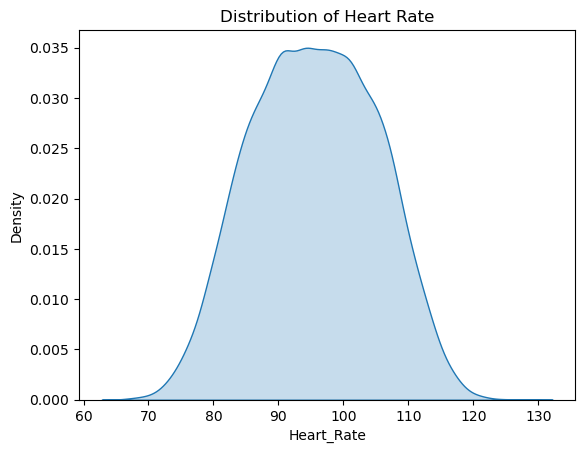

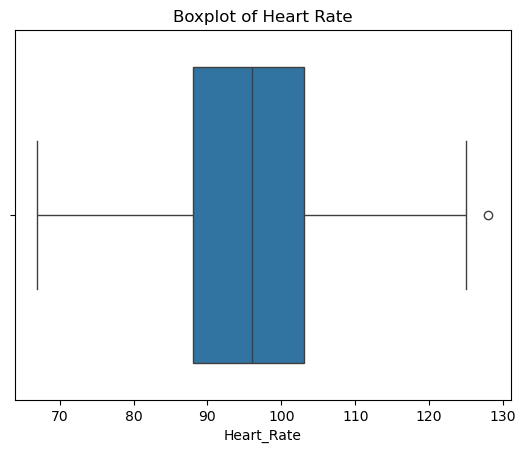

In [540]:
#Kde Plot
sns.kdeplot(data=df,x='Heart_Rate',fill=True)
plt.title('Distribution of Heart Rate')
plt.show()

#BoxPlot
sns.boxplot(x=df['Heart_Rate'])
plt.title('Boxplot of Heart Rate')
plt.show()

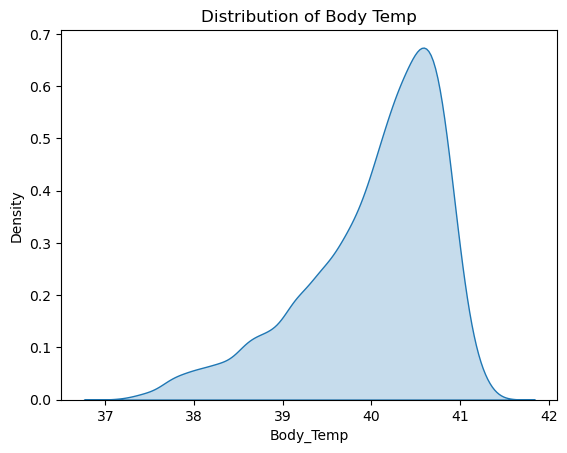

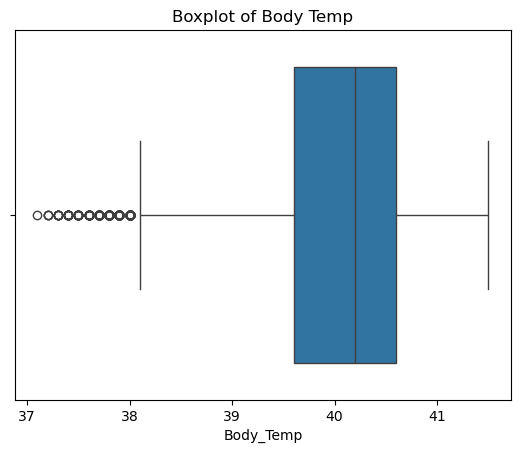

In [541]:
#Kde Plot
sns.kdeplot(data=df,x='Body_Temp',fill=True)
plt.title('Distribution of Body Temp')
plt.show()

#BoxPlot
sns.boxplot(x=df['Body_Temp'])
plt.title('Boxplot of Body Temp')
plt.show()

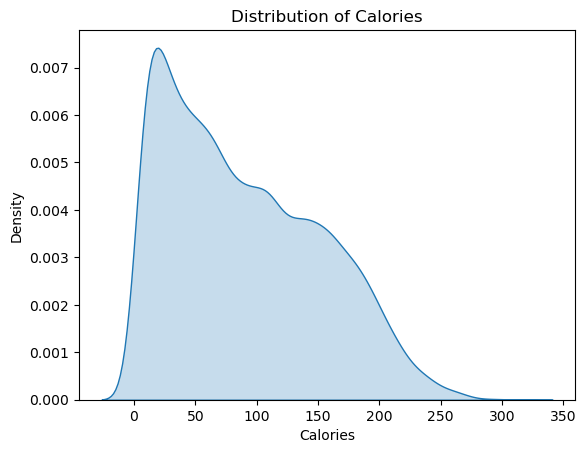

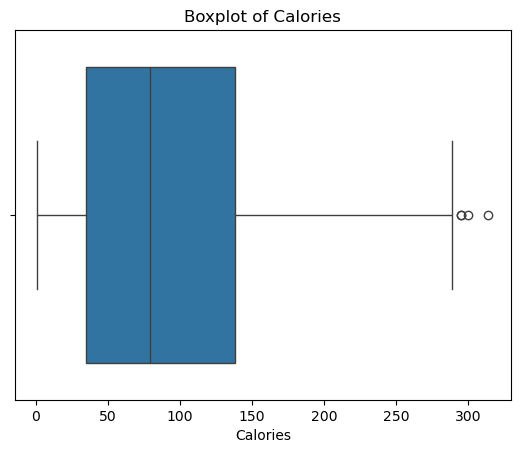

In [542]:
#Kde Plot
sns.kdeplot(data=df,x='Calories',fill=True)
plt.title('Distribution of Calories')
plt.show()

#BoxPlot
sns.boxplot(x=df['Calories'])
plt.title('Boxplot of Calories')
plt.show()

## Univariate Analysis on Categorical Column

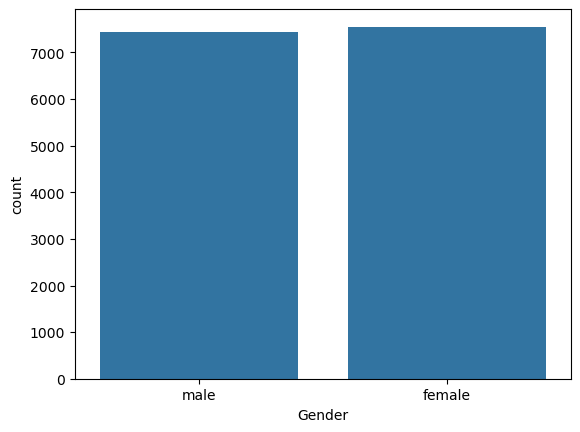

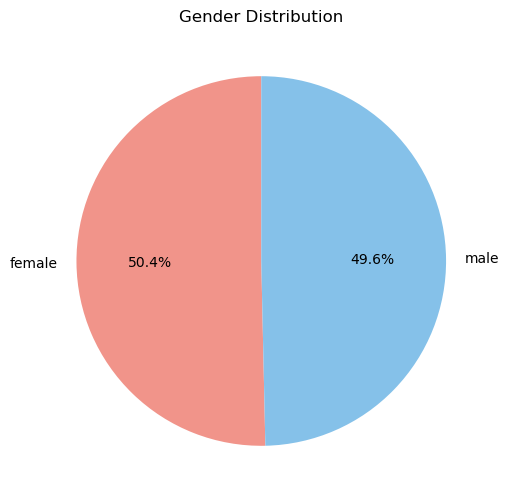

In [543]:
sns.countplot(x='Gender', data=df)

plt.figure(figsize=(6,6))
df['Gender'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, 
                                    colors=['#f1948a','#85c1e9'])
plt.ylabel('')
plt.title('Gender Distribution')
plt.show()

## Bivariate and Multivariate Analysis

### Numerical vs Numerical plots

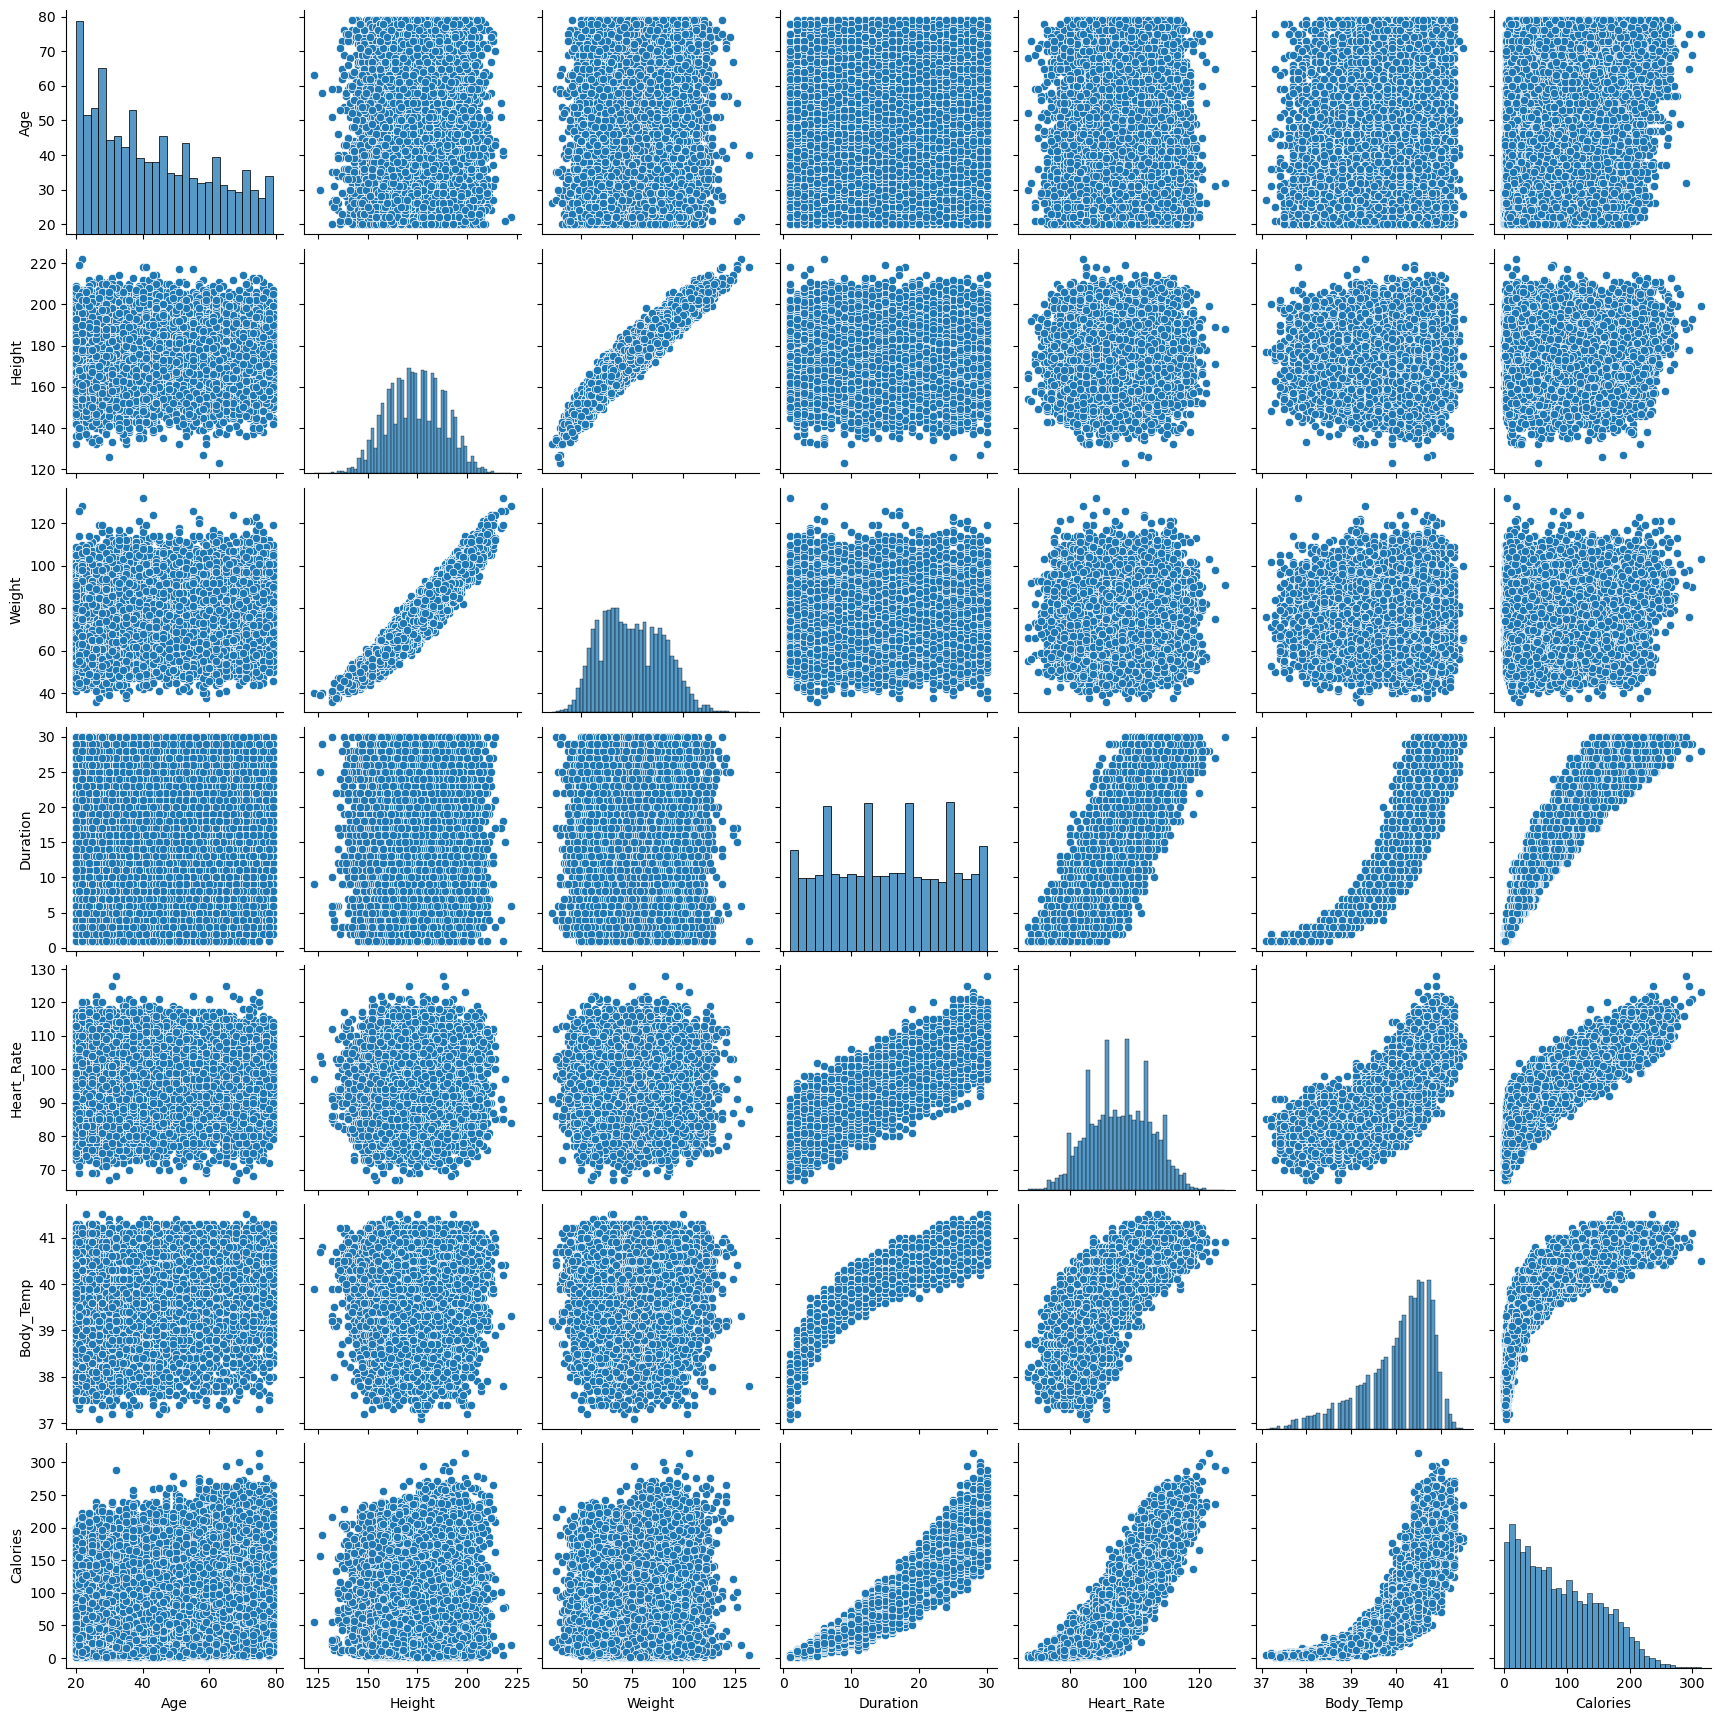

In [544]:
sns.pairplot(df[['Age', 'Height', 'Weight','Duration','Heart_Rate','Body_Temp','Calories']], palette='Set1')
plt.show()

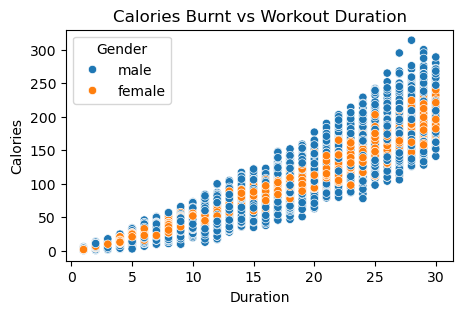

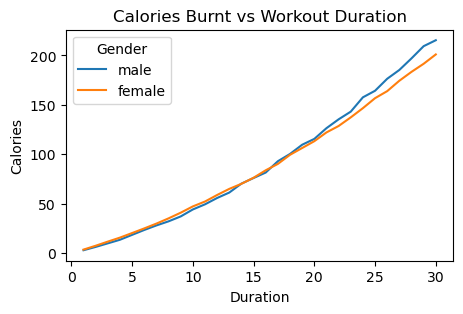

In [545]:
# Duration vs Calories (Workout Effectiveness)
plt.figure(figsize=(5, 3))
sns.scatterplot(x='Duration', y='Calories', hue='Gender', data=df)
plt.title("Calories Burnt vs Workout Duration")
plt.show()

plt.figure(figsize=(5, 3))
sns.lineplot(x='Duration', y='Calories', hue='Gender', data=df,ci=None)
plt.title("Calories Burnt vs Workout Duration")
plt.show()

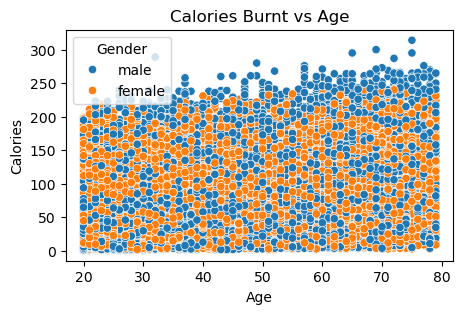

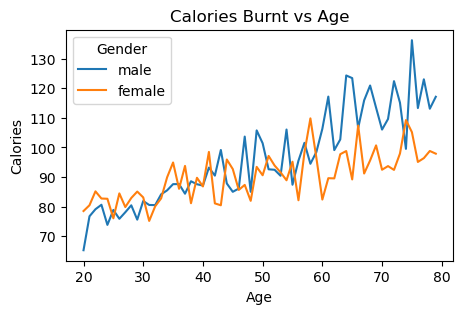

In [546]:
# Age vs Calories (Workout Effectiveness)
plt.figure(figsize=(5, 3))
sns.scatterplot(x='Age', y='Calories', hue='Gender', data=df)
plt.title("Calories Burnt vs Age")
plt.show()

plt.figure(figsize=(5, 3))
sns.lineplot(x='Age', y='Calories', hue='Gender', data=df,ci=None)
plt.title("Calories Burnt vs Age")
plt.show()


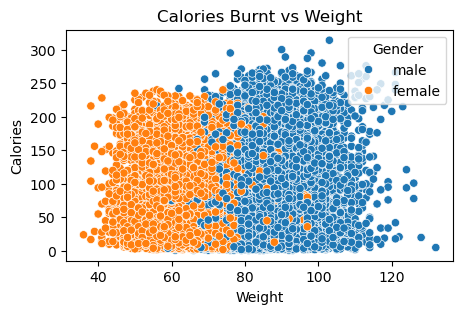

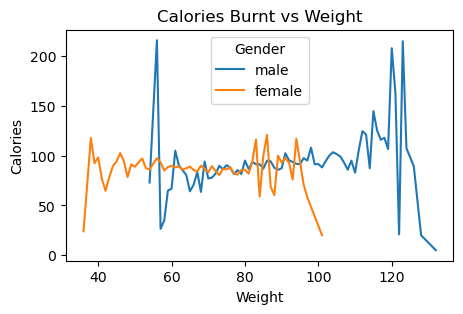

In [547]:
# Weight vs Calories (Workout Effectiveness)
plt.figure(figsize=(5, 3))
sns.scatterplot(x='Weight', y='Calories', hue='Gender', data=df)
plt.title("Calories Burnt vs Weight")
plt.show()

plt.figure(figsize=(5, 3))
sns.lineplot(x='Weight', y='Calories', hue='Gender', data=df,ci=None)
plt.title("Calories Burnt vs Weight")
plt.show()

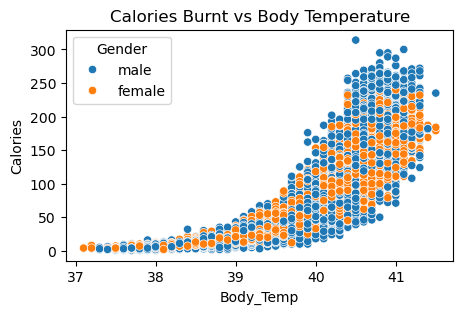

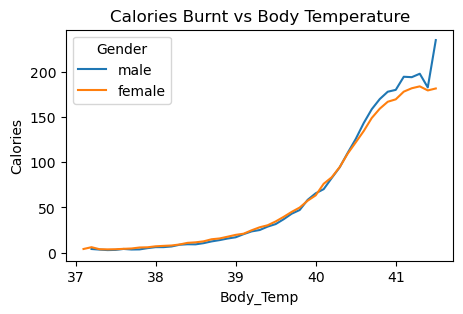

In [548]:
# Body Temperature vs Calories (Workout Effectiveness)
plt.figure(figsize=(5, 3))
sns.scatterplot(x='Body_Temp', y='Calories', hue='Gender', data=df)
plt.title("Calories Burnt vs Body Temperature")
plt.show()

plt.figure(figsize=(5, 3))
sns.lineplot(x='Body_Temp', y='Calories', hue='Gender', data=df,ci=None)
plt.title("Calories Burnt vs Body Temperature")
plt.show()

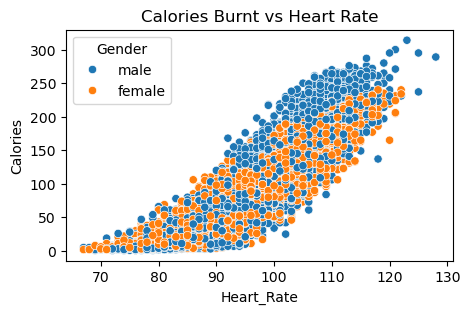

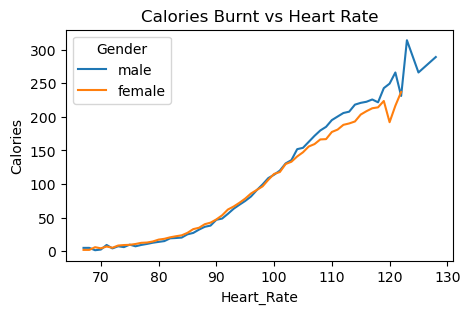

In [549]:
# Heart Rate vs Calories (Workout Effectiveness)
plt.figure(figsize=(5, 3))
sns.scatterplot(x='Heart_Rate', y='Calories', hue='Gender', data=df)
plt.title("Calories Burnt vs Heart Rate")
plt.show()

plt.figure(figsize=(5, 3))
sns.lineplot(x='Heart_Rate', y='Calories', hue='Gender', data=df,ci=None)
plt.title("Calories Burnt vs Heart Rate")
plt.show()

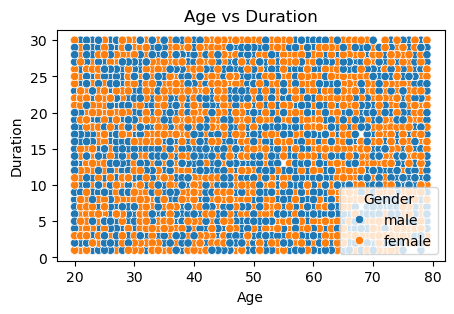

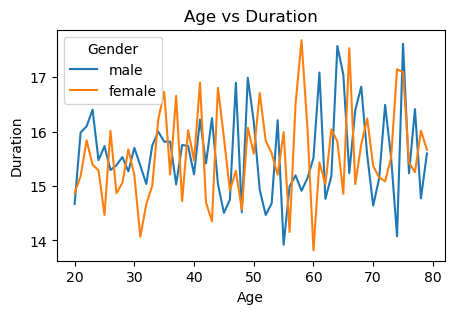

In [550]:
# Age vs Duration (Workout Effectiveness)
plt.figure(figsize=(5, 3))
sns.scatterplot(x='Age', y='Duration', hue='Gender', data=df)
plt.title("Age vs Duration")
plt.show()

plt.figure(figsize=(5, 3))
sns.lineplot(x='Age', y='Duration', hue='Gender', data=df,ci=None)
plt.title("Age vs Duration")
plt.show()

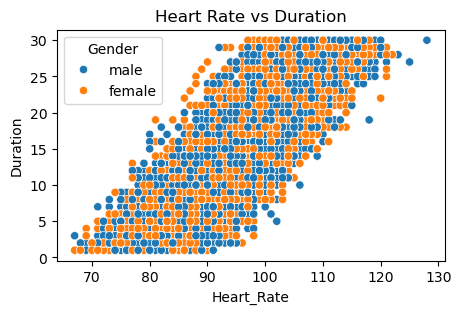

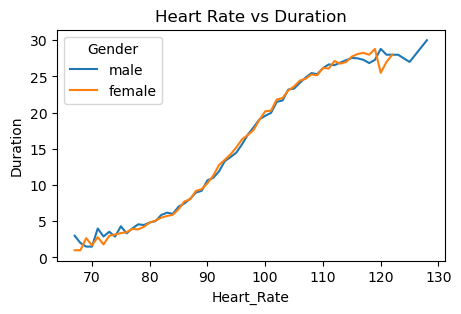

In [551]:
# Heart Rate vs Duration (Workout Effectiveness)
plt.figure(figsize=(5, 3))
sns.scatterplot(x='Heart_Rate', y='Duration', hue='Gender', data=df)
plt.title("Heart Rate vs Duration")
plt.show()

plt.figure(figsize=(5, 3))
sns.lineplot(x='Heart_Rate', y='Duration', hue='Gender', data=df,ci=None)
plt.title("Heart Rate vs Duration")
plt.show()

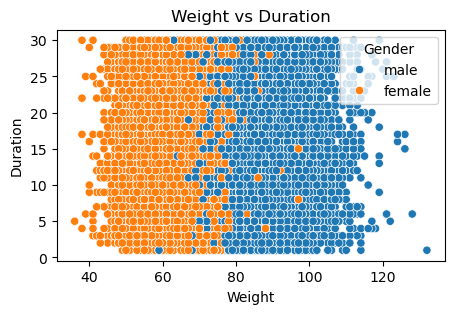

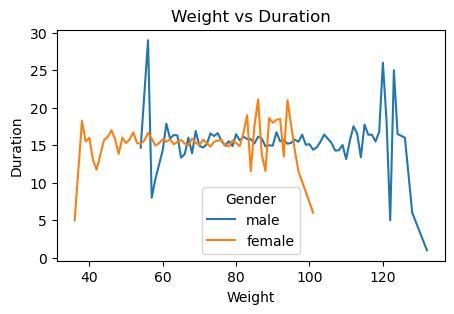

In [552]:
# Weight vs Heart Rate (Workout Effectiveness)
plt.figure(figsize=(5, 3))
sns.scatterplot(x='Weight', y='Duration', hue='Gender', data=df)
plt.title("Weight vs Duration")
plt.show()

plt.figure(figsize=(5, 3))
sns.lineplot(x='Weight', y='Duration', hue='Gender', data=df,ci=None)
plt.title("Weight vs Duration")
plt.show()

### Numerical Vs Categorical Plots

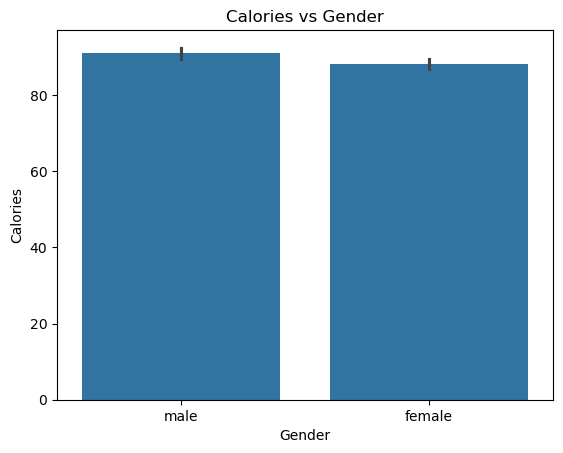

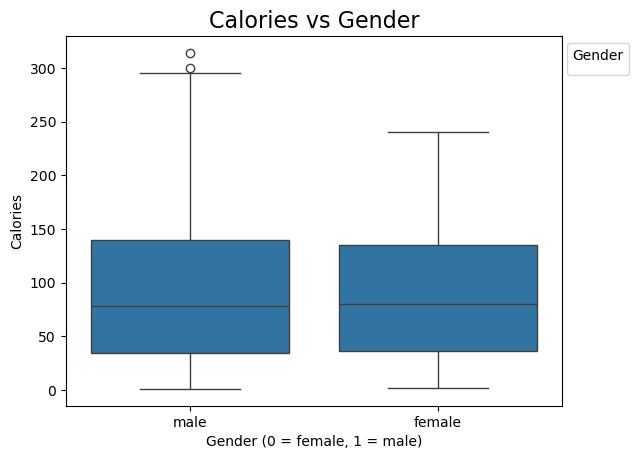

In [553]:
sns.barplot(x='Gender', y='Calories', data=df)
plt.title('Calories vs Gender')
plt.show()

sns.boxplot(x='Gender', y='Calories', data=df)
plt.title('Calories vs Gender', fontsize=16)
plt.xlabel('Gender (0 = female, 1 = male)')
plt.ylabel('Calories')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=["Male", "Female"], title="Gender", loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()


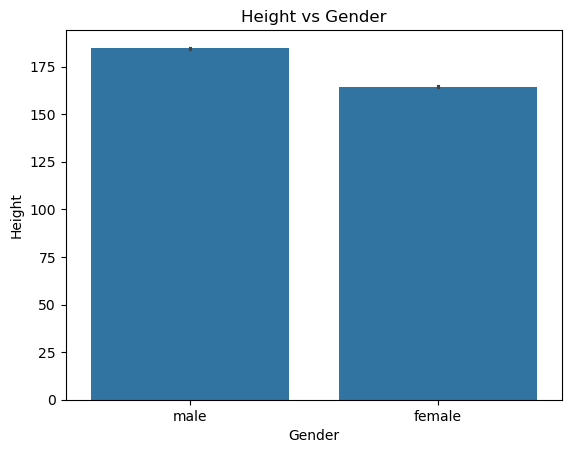

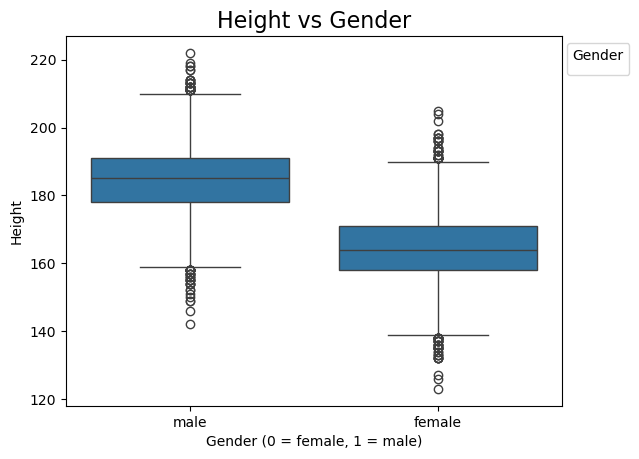

In [554]:
sns.barplot(x='Gender', y='Height', data=df)
plt.title('Height vs Gender')
plt.show()

sns.boxplot(x='Gender', y='Height', data=df)
plt.title('Height vs Gender', fontsize=16)
plt.xlabel('Gender (0 = female, 1 = male)')
plt.ylabel('Height')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=["Male", "Female"], title="Gender", loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()


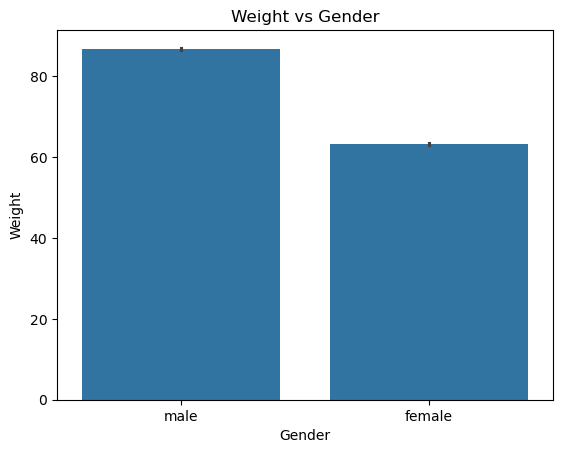

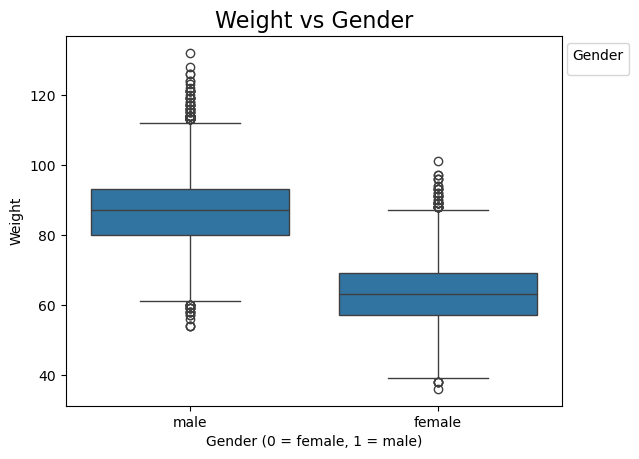

In [555]:
sns.barplot(x='Gender', y='Weight', data=df)
plt.title('Weight vs Gender')
plt.show()

sns.boxplot(x='Gender', y='Weight', data=df)
plt.title('Weight vs Gender', fontsize=16)
plt.xlabel('Gender (0 = female, 1 = male)')
plt.ylabel('Weight')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=["Male", "Female"], title="Gender", loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()


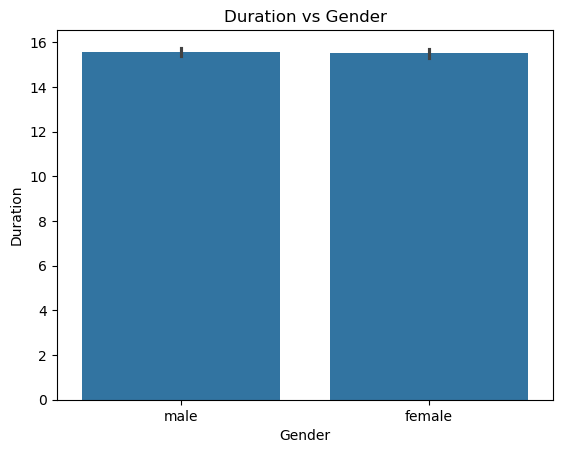

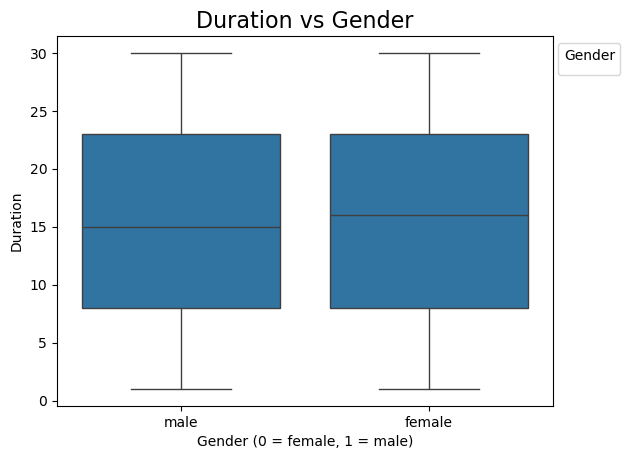

In [556]:
sns.barplot(x='Gender', y='Duration', data=df)
plt.title('Duration vs Gender')
plt.show()

sns.boxplot(x='Gender', y='Duration', data=df)
plt.title('Duration vs Gender', fontsize=16)
plt.xlabel('Gender (0 = female, 1 = male)')
plt.ylabel('Duration')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=["Male", "Female"], title="Gender", loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()


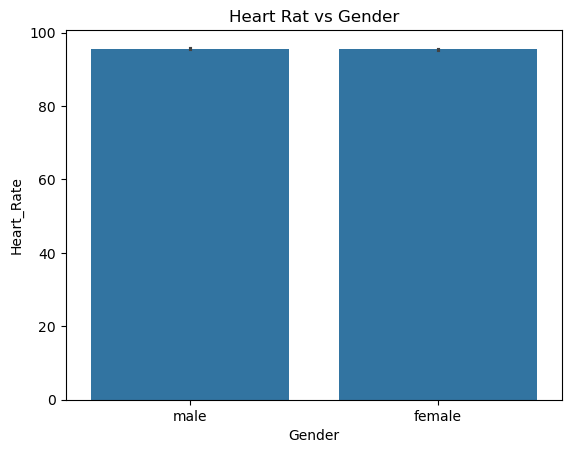

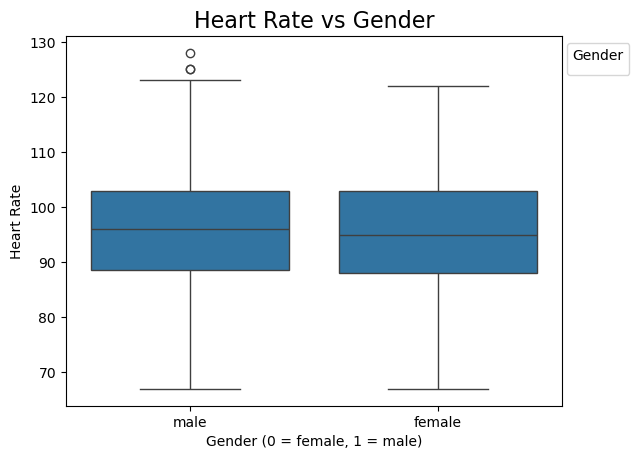

In [557]:
sns.barplot(x='Gender', y='Heart_Rate', data=df)
plt.title('Heart Rat vs Gender')
plt.show()

sns.boxplot(x='Gender', y='Heart_Rate', data=df)
plt.title('Heart Rate vs Gender', fontsize=16)
plt.xlabel('Gender (0 = female, 1 = male)')
plt.ylabel('Heart Rate')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=["Male", "Female"], title="Gender", loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()


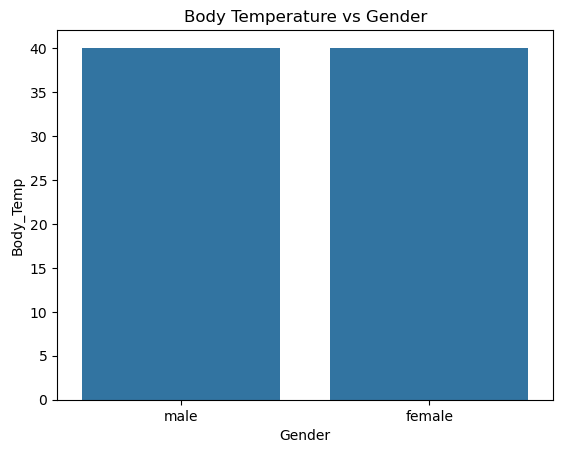

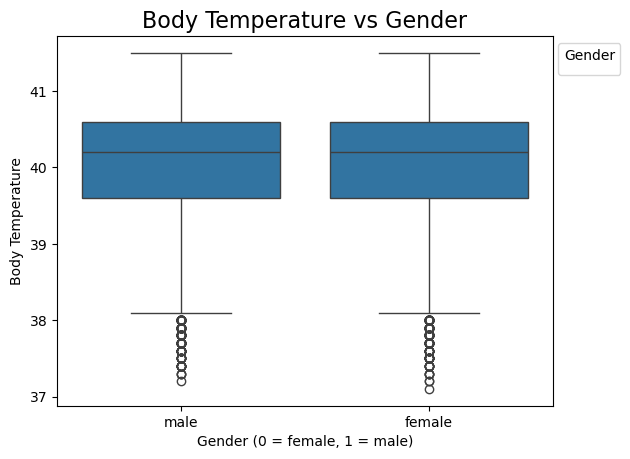

In [558]:
sns.barplot(x='Gender', y='Body_Temp', data=df)
plt.title('Body Temperature vs Gender')
plt.show()

sns.boxplot(x='Gender', y='Body_Temp', data=df)
plt.title('Body Temperature vs Gender', fontsize=16)
plt.xlabel('Gender (0 = female, 1 = male)')
plt.ylabel('Body Temperature')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=["Male", "Female"], title="Gender", loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()


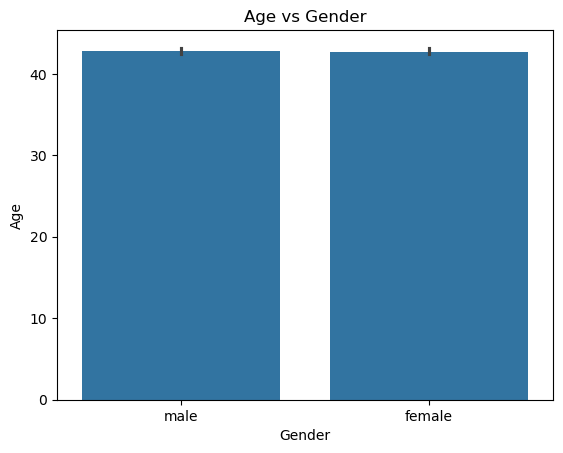

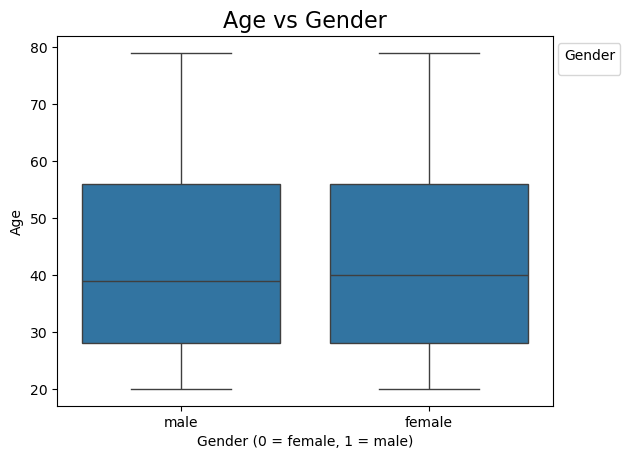

In [559]:
sns.barplot(x='Gender', y='Age', data=df)
plt.title('Age vs Gender')
plt.show()

sns.boxplot(x='Gender', y='Age', data=df)
plt.title('Age vs Gender', fontsize=16)
plt.xlabel('Gender (0 = female, 1 = male)')
plt.ylabel('Age')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=["Male", "Female"], title="Gender", loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()


# Removing Outlier

In [560]:
# Removal of outlier from height column
Q1 = df['Height'].quantile(0.25)
Q3 = df['Height'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['Height'] = df['Height'].clip(lower=lower_bound, upper=upper_bound)

In [561]:
# Removal of outlier from weight column
Q1 = df['Weight'].quantile(0.25)
Q3 = df['Weight'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['Weight'] = df['Weight'].clip(lower=lower_bound, upper=upper_bound)

In [562]:
# Removal of outlier from Heart_Rate column
Q1 = df['Heart_Rate'].quantile(0.25)
Q3 = df['Heart_Rate'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['Heart_Rate'] = df['Heart_Rate'].clip(lower=lower_bound, upper=upper_bound)

In [563]:
# Removal of outlier from Body_Temp column
Q1 = df['Body_Temp'].quantile(0.25)
Q3 = df['Body_Temp'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['Body_Temp'] = df['Body_Temp'].clip(lower=lower_bound, upper=upper_bound)

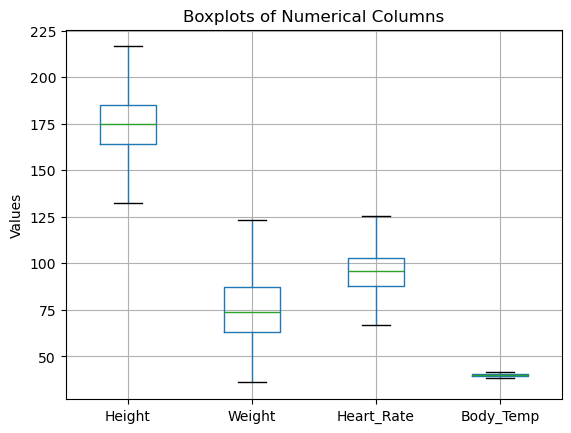

In [564]:
cols = ['Height', 'Weight', 'Heart_Rate', 'Body_Temp'] 

df[cols].boxplot()
plt.title('Boxplots of Numerical Columns')
plt.ylabel('Values')
plt.show()

In [565]:
df.shape

(15000, 9)

# ONE HOT ENCODING

In [566]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['Gender']
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_array = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(categorical_cols))
df = pd.concat([df.drop(columns=categorical_cols), encoded_df], axis=1)
df.head()


,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,Gender_male
0,14733363,68,190.0,94.0,29.0,105.0,40.8,231.0,1.0
1,14861698,20,166.0,60.0,14.0,94.0,40.3,66.0,0.0
2,11179863,69,179.0,79.0,5.0,88.0,38.7,26.0,1.0
3,16180408,34,179.0,71.0,13.0,100.0,40.5,71.0,0.0
4,17771927,27,154.0,58.0,10.0,81.0,39.8,35.0,0.0


In [567]:
df.rename(columns={'Gender_male': 'Gender'}, inplace=True)

In [568]:
df.head()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,Gender
0,14733363,68,190.0,94.0,29.0,105.0,40.8,231.0,1.0
1,14861698,20,166.0,60.0,14.0,94.0,40.3,66.0,0.0
2,11179863,69,179.0,79.0,5.0,88.0,38.7,26.0,1.0
3,16180408,34,179.0,71.0,13.0,100.0,40.5,71.0,0.0
4,17771927,27,154.0,58.0,10.0,81.0,39.8,35.0,0.0


In [569]:
df.isnull().sum()

User_ID       0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
Gender        0
dtype: int64

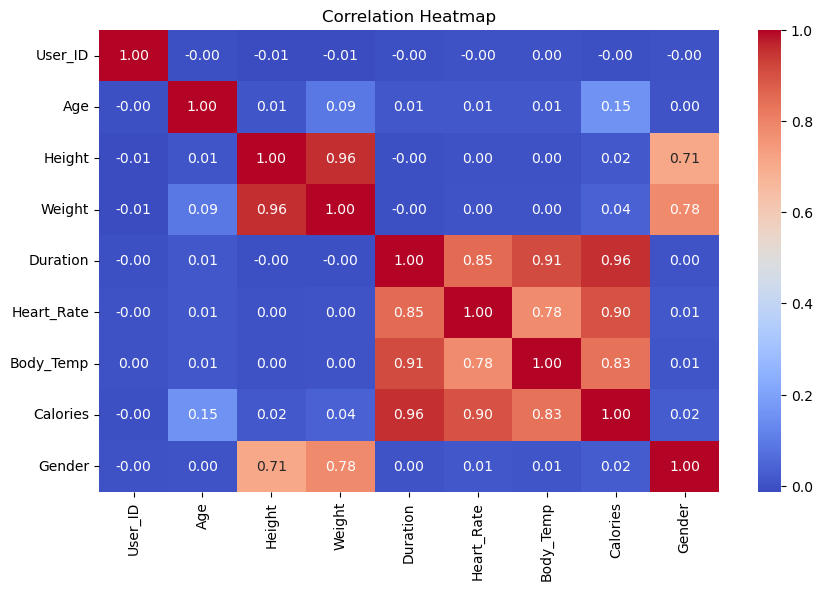

In [570]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


# Traning Models

In [583]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn import metrics
from sklearn.preprocessing import StandardScaler

In [572]:
X = df.drop(['Calories','User_ID'], axis=1)
y = df['Calories']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Selection with Cross-Validation 

## XGBoost Regressor

In [573]:
xgb = XGBRegressor(random_state=42, eval_metric='rmse')
kf = KFold(n_splits=5, shuffle=True, random_state=42)
X_used = X_train  

r2_scores = cross_val_score(xgb, X_used, y_train, cv=kf, scoring='r2')
mae_scores = -cross_val_score(xgb, X_used, y_train, cv=kf, scoring='neg_mean_absolute_error')
mse_scores = -cross_val_score(xgb, X_used, y_train, cv=kf, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(mse_scores)

print("--- XGBoost Regressor ---")
print("Mean R2:", np.mean(r2_scores))
print("Mean MAE:", np.mean(mae_scores))
print("Mean MSE:", np.mean(mse_scores))
print("Mean RMSE:", np.mean(rmse_scores))

--- XGBoost Regressor ---
Mean R2: 0.998643559540805
Mean MAE: 1.5662767303499083
Mean MSE: 5.243329652139527
Mean RMSE: 2.289038660802805


## Linear Regression

In [574]:
lr = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=42)
X_used = X_train_scaled  

r2_scores = cross_val_score(lr, X_used, y_train, cv=kf, scoring='r2')
mae_scores = -cross_val_score(lr, X_used, y_train, cv=kf, scoring='neg_mean_absolute_error')
mse_scores = -cross_val_score(lr, X_used, y_train, cv=kf, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(mse_scores)

print("--- Linear Regression ---")
print("Mean R2:", np.mean(r2_scores))
print("Mean MAE:", np.mean(mae_scores))
print("Mean MSE:", np.mean(mse_scores))
print("Mean RMSE:", np.mean(rmse_scores))

--- Linear Regression ---
Mean R2: 0.9669893145014162
Mean MAE: 8.333010450206876
Mean MSE: 127.58169676871312
Mean RMSE: 11.294011483030872


## Random Forest Regressor

In [575]:
rf = RandomForestRegressor(random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
X_used = X_train  

r2_scores = cross_val_score(rf, X_used, y_train, cv=kf, scoring='r2')
mae_scores = -cross_val_score(rf, X_used, y_train, cv=kf, scoring='neg_mean_absolute_error')
mse_scores = -cross_val_score(rf, X_used, y_train, cv=kf, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(mse_scores)

print("--- Random Forest ---")
print("Mean R2:", np.mean(r2_scores))
print("Mean MAE:", np.mean(mae_scores))
print("Mean MSE:", np.mean(mse_scores))
print("Mean RMSE:", np.mean(rmse_scores))

--- Random Forest ---
Mean R2: 0.9976183612220957
Mean MAE: 1.8793558333333333
Mean MSE: 9.204913708333333
Mean RMSE: 3.0310147356800807


## Decision Tree Regressor 

In [577]:
dt = DecisionTreeRegressor(random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
X_used = X_train  

r2_scores = cross_val_score(dt, X_used, y_train, cv=kf, scoring='r2')
mae_scores = -cross_val_score(dt, X_used, y_train, cv=kf, scoring='neg_mean_absolute_error')
mse_scores = -cross_val_score(dt, X_used, y_train, cv=kf, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(mse_scores)

print("--- Decision Tree ---")
print("Mean R2:", np.mean(r2_scores))
print("Mean MAE:", np.mean(mae_scores))
print("Mean MSE:", np.mean(mse_scores))
print("Mean RMSE:", np.mean(rmse_scores))

--- Decision Tree ---
Mean R2: 0.9919921021190812
Mean MAE: 3.585416666666667
Mean MSE: 30.962416666666666
Mean RMSE: 5.560478181912759


##### Observation: XGBoost Regressor is best performing

# Hyperparameter Tuning

## XGBoost Regressor

In [584]:
param_grid = {
    'n_estimators': [100, 200, 250, 300, 350, 400, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2]
}
model = XGBRegressor(objective='reg:squarederror', random_state=42)

# Grid Search with 5-fold CV
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Print results
print("Grid Search Results:")
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validated R2 Score:", grid_search.best_score_)

Grid Search Results:
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 500}
Best Cross-Validated R2 Score: 0.9993961129960273


# Final Evaluation 

## XGBoost Regressor

In [589]:
model = XGBRegressor(learnini_rate=0.1,max_depth=5,n_estimator=500,random_state=42)
model.fit(X_train, y_train)
test_data_prediction = model.predict(X_test)

mae = metrics.mean_absolute_error(y_test, test_data_prediction)
r2 = metrics.r2_score(y_test, test_data_prediction)
mse = metrics.mean_squared_error(y_test, test_data_prediction)
rmse = np.sqrt(mse)

print("Mean Absolute Error = ", mae)
print("R2 Score:", r2)
print("Root Mean Squared Error:", rmse)
print("Mean Squared Error:", mse)

Mean Absolute Error =  1.5779553543925284
R2 Score: 0.9988372255875124
Root Mean Squared Error: 2.166267542105188
Mean Squared Error: 4.6927150639784525
